In [12]:
import os
# Desactivamos los GPUs para evitar warnings si no los tienes configurados
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

from tensorflow.keras.metrics import BinaryAccuracy

In [13]:
keypoints_data = pd.read_csv(
    'D:/la-u/ciclo 2025-1/Seminario/Proyecto/DATASETS_CSV/keypoints_padded_with_mask.csv'
)
labels_data = pd.read_csv(
    'D:/la-u/ciclo 2025-1/Seminario/Proyecto/DATASETS_CSV/dataset_errores.csv',
    sep=','
)

# Limpiamos espacios en blanco
keypoints_data['video_filename'] = keypoints_data['video_filename'].str.strip()
labels_data['nombre_video']    = labels_data['nombre_video'].str.strip()



In [14]:
landmarks_to_keep = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
print(f"Número de landmarks seleccionados: {len(landmarks_to_keep)}")

# Filtramos únicamente las filas que pertenecen a esos landmarks
keypoints_data = keypoints_data[keypoints_data['landmark_index'].isin(landmarks_to_keep)].reset_index(drop=True)

# Convertimos la columna “lado” a numérico: 0 = Izquierdo, 1 = Derecho
labels_data['lado'] = labels_data['lado'].map({'I': 0, 'D': 1})

error_cols = [
    'giro_incompleto', 'pierna_patea_flexionada', 'pierna_base_flexionada',
    'pie_sin_borde_externo', 'preparacion_incompleta', 'recojida_incompleta'
]
all_cols = error_cols + ['lado']
labels_dict = labels_data.set_index('nombre_video')[all_cols].to_dict(orient='index')


Número de landmarks seleccionados: 12


In [15]:
video_frames = {}
for (video, frame), group in keypoints_data.groupby(['video_filename', 'frame']):
    group_sorted = group.sort_values(by='landmark_index')
    frame_vector = group_sorted[['x', 'y', 'z', 'visibility']].values.flatten()
    video_frames.setdefault(video, []).append(frame_vector)

fixed_frame_count = max(len(frames) for frames in video_frames.values())
frame_dim = len(landmarks_to_keep) * 4

print(f"Frames por video (fijo): {fixed_frame_count}, features por frame: {frame_dim}")

X_flat = []
video_names = []
for video, frames in video_frames.items():
    assert len(frames) == fixed_frame_count, f"Video {video} no tiene {fixed_frame_count} frames"
    video_vector = np.array(frames).flatten()
    X_flat.append(video_vector)
    video_names.append(video)

X_flat = np.array(X_flat)
num_videos = X_flat.shape[0]
print("X_flat.shape:", X_flat.shape)

X = X_flat.reshape((num_videos, fixed_frame_count, frame_dim)).astype('float32')
print("X (3D) shape:", X.shape)


Frames por video (fijo): 162, features por frame: 48
X_flat.shape: (500, 7776)
X (3D) shape: (500, 162, 48)


In [16]:
y_list = []
for video in video_names:
    if video in labels_dict:
        y_list.append([labels_dict[video][col] for col in all_cols])
    else:
        print(f"Advertencia: etiqueta faltante para {video}, se pone vector cero.")
        y_list.append([0] * len(all_cols))

y = np.array(y_list).astype('float32')
print("y shape:", y.shape)


y shape: (500, 7)


In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print("Shapes después del split:")
print("  X_train:", X_train.shape, "X_val:", X_val.shape)
print("  y_train:", y_train.shape, "y_val:", y_val.shape)


Shapes después del split:
  X_train: (400, 162, 48) X_val: (100, 162, 48)
  y_train: (400, 7) y_val: (100, 7)


In [18]:
def scale_preserving_padding(X_split):
    """
    X_split: array de forma (num_videos_split, num_frames, frame_dim)
    Devuelve: X_scaled, mask_binary, scaler
    - X_scaled: array escalado donde los frames totalmente zero siguen siendo zero
    - mask_binary: booleans indicando qué frames eran cero originalmente
    - scaler: el objeto StandardScaler ajustado sobre filas no-cero
    """
    ns, nf, nd = X_split.shape
    X_flat = X_split.reshape(-1, nd)  # (ns * nf, nd)
    zero_rows = np.all(X_flat == 0.0, axis=1)  # vector de tamaño (ns*nf)

    scaler = StandardScaler()
    non_zero_idx = np.where(~zero_rows)[0]
    if len(non_zero_idx) == 0:
        # Si todas las filas son cero, no hay nada que escalar
        return X_split.copy(), zero_rows.reshape(ns, nf), None

    # Ajustamos el scaler con las filas no-padding
    scaler.fit(X_flat[non_zero_idx, :])
    # Transformamos todo el tensor
    X_scaled_flat = scaler.transform(X_flat)
    # Ponemos a cero absoluto las filas que eran padding
    X_scaled_flat[zero_rows, :] = 0.0

    X_scaled = X_scaled_flat.reshape(ns, nf, nd).astype('float32')
    return X_scaled, zero_rows.reshape(ns, nf), scaler

# Aplicamos a train y val
X_train_scaled, mask_train, scaler = scale_preserving_padding(X_train)
X_val_scaled, mask_val, _ = scale_preserving_padding(X_val)

print("‘Padded mask’ train shape:", mask_train.shape)
print("‘Padded mask’ val shape:", mask_val.shape)


‘Padded mask’ train shape: (400, 162)
‘Padded mask’ val shape: (100, 162)


In [19]:
num_frames = fixed_frame_count
num_features = frame_dim
num_labels = y_train.shape[1]

input_seq = Input(shape=(num_frames, num_features), name='input_secuencia')
mask_layer = layers.Masking(mask_value=0.0, name='masking')(input_seq)

x = layers.Bidirectional(
    layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l2(1e-4)),
    name='bidi_lstm_128'
)(mask_layer)
x = layers.Dropout(0.5, name='dropout_1')(x)

x = layers.LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l2(1e-4), name='lstm_64')(x)
x = layers.Dropout(0.4, name='dropout_2')(x)

x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name='dense_64')(x)
x = layers.Dropout(0.4, name='dropout_3')(x)

x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name='dense_32')(x)
x = layers.Dropout(0.4, name='dropout_4')(x)

output = layers.Dense(num_labels, activation='sigmoid', name='output')(x)

model = Model(inputs=input_seq, outputs=output, name='modelo_patada_lateral')

metrics_list = ['accuracy']
for label_name in all_cols:
    # la capa de salida se llama "output", pero Keras infiere la posición de cada unidad.
    # Aquí nombramos cada métrica con un string único.
    metrics_list.append(BinaryAccuracy(name=f'acc_{label_name}', dtype=tf.float32))



model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=metrics_list
)
model.summary()


Model: "modelo_patada_lateral"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_secuencia (InputLayer  [(None, 162, 48)]        0         
 )                                                               
                                                                 
 masking (Masking)           (None, 162, 48)           0         
                                                                 
 bidi_lstm_128 (Bidirectiona  (None, 162, 256)         181248    
 l)                                                              
                                                                 
 dropout_1 (Dropout)         (None, 162, 256)          0         
                                                                 
 lstm_64 (LSTM)              (None, 64)                82176     
                                                                 
 dropout_2 (Dropout)         (None, 64)      

In [20]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.h5', monitor='val_loss', save_best_only=True, verbose=1
    )
]

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=8,
    callbacks=callbacks,
    verbose=2
)


Epoch 1/100

Epoch 1: val_loss improved from inf to 0.48297, saving model to best_model.h5
50/50 - 13s - loss: 0.6226 - accuracy: 0.2075 - acc_giro_incompleto: 0.7029 - acc_pierna_patea_flexionada: 0.7029 - acc_pierna_base_flexionada: 0.7029 - acc_pie_sin_borde_externo: 0.7029 - acc_preparacion_incompleta: 0.7029 - acc_recojida_incompleta: 0.7029 - acc_lado: 0.7029 - val_loss: 0.4830 - val_accuracy: 0.3100 - val_acc_giro_incompleto: 0.8400 - val_acc_pierna_patea_flexionada: 0.8400 - val_acc_pierna_base_flexionada: 0.8400 - val_acc_pie_sin_borde_externo: 0.8400 - val_acc_preparacion_incompleta: 0.8400 - val_acc_recojida_incompleta: 0.8400 - val_acc_lado: 0.8400 - 13s/epoch - 268ms/step
Epoch 2/100

Epoch 2: val_loss improved from 0.48297 to 0.43440, saving model to best_model.h5
50/50 - 4s - loss: 0.4816 - accuracy: 0.3525 - acc_giro_incompleto: 0.8021 - acc_pierna_patea_flexionada: 0.8021 - acc_pierna_base_flexionada: 0.8021 - acc_pie_sin_borde_externo: 0.8021 - acc_preparacion_incompl

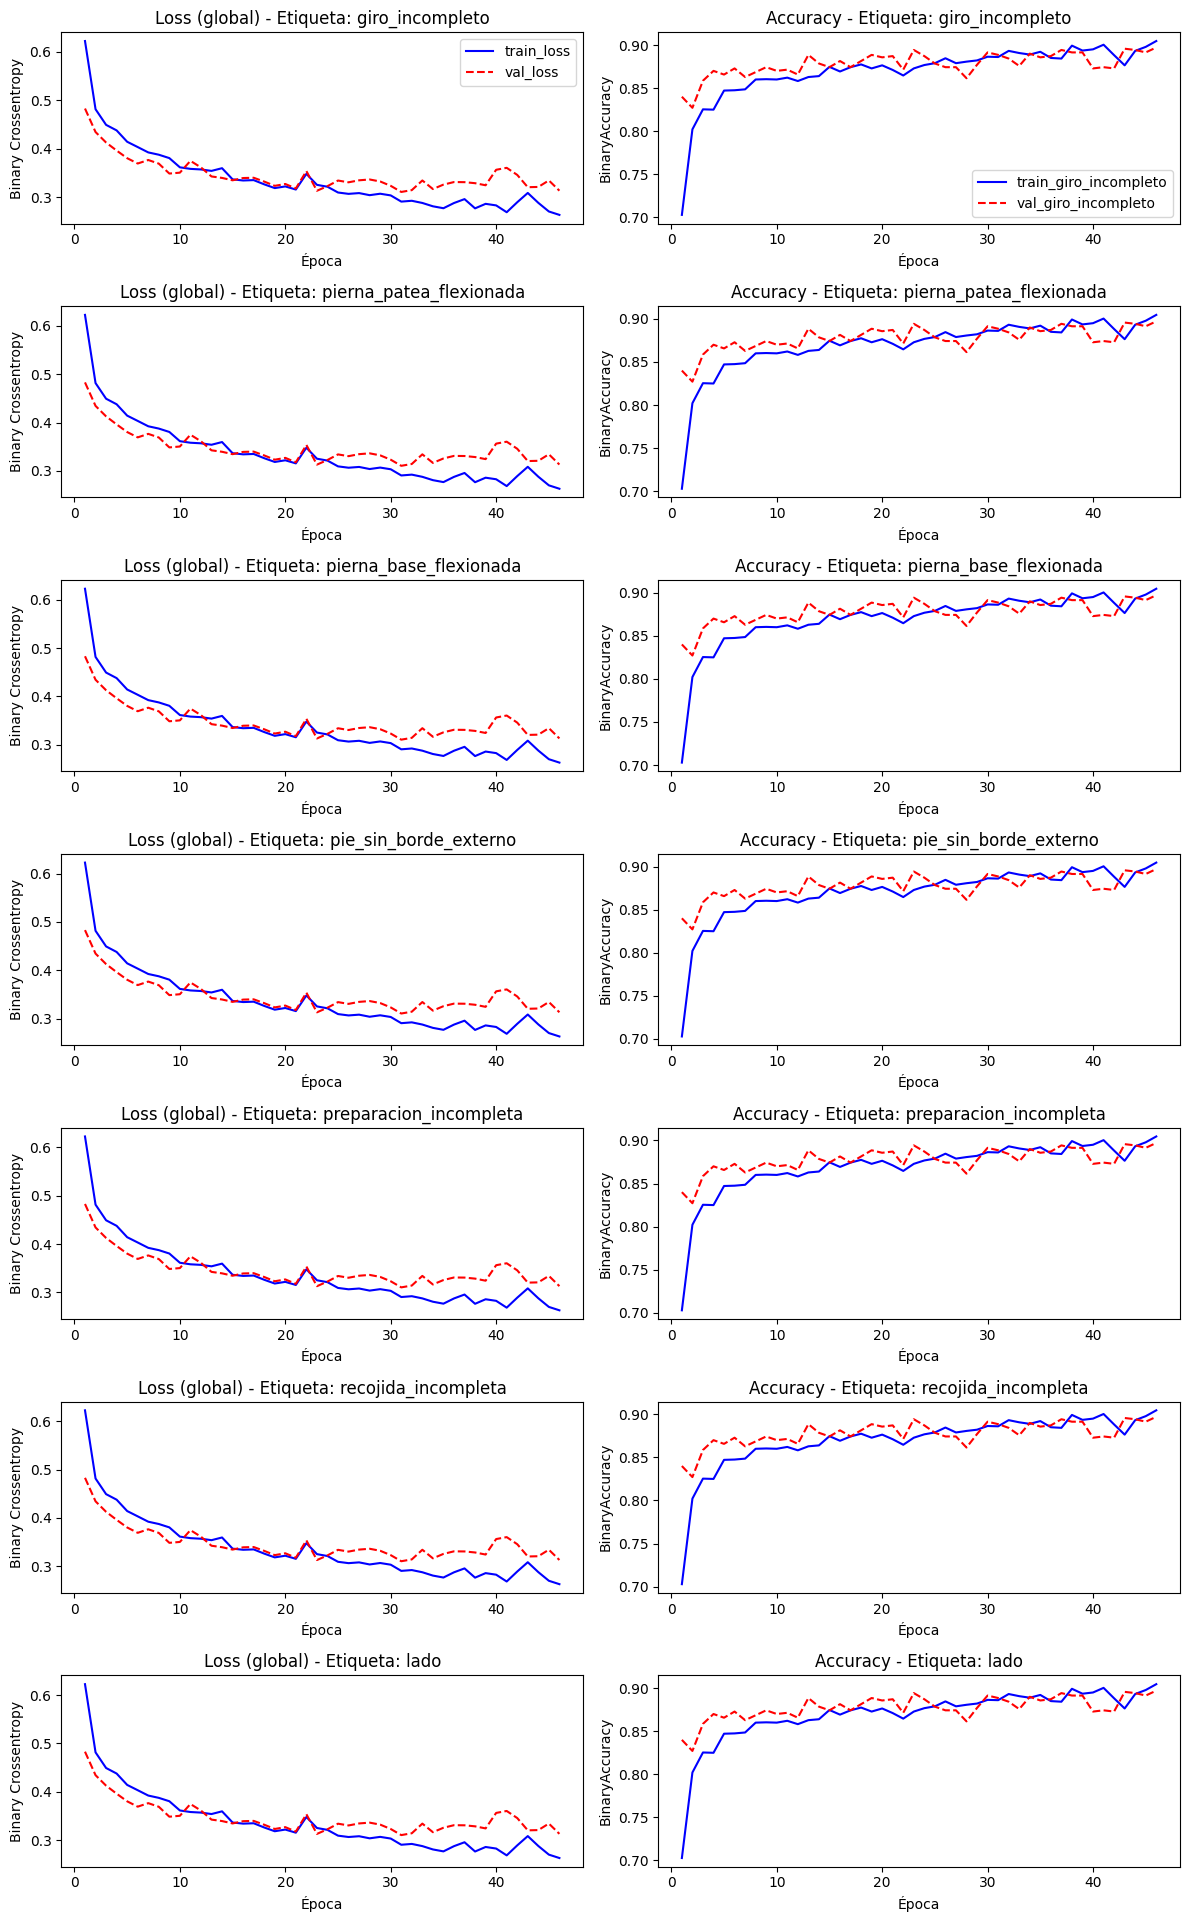

In [25]:
def plot_per_label_curves(history, label_names):
    """
    Grafica Loss y Accuracy (binaria) para cada etiqueta a lo largo de las épocas.
    
    Parámetros:
    - history: objeto devuelto por model.fit(...)
    - label_names: lista de cadenas con nombre de cada etiqueta, mismo orden que al compilar.
    """
    n_labels = len(label_names)
    # Definimos un subplot con dos columnas: una para loss, otra para accuracy,
    # y n_labels filas (o agrupamos en bloques).
    # Para mayor legibilidad, dibujamos 2 columnas x n_labels filas:
    fig, axes = plt.subplots(n_labels, 2, figsize=(12, 3 * n_labels))
    # fig.suptitle('Evolución por época: Loss y Accuracy por etiqueta', fontsize=18, y=0.92)
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    for idx, lab in enumerate(label_names):
        # Nombres de las claves en history.history:
        key_acc   = f'acc_{lab}'
        key_val_acc = f'val_acc_{lab}'
        
        # Loss que entregó Keras es global (no por etiqueta), así que repetimos: 
        #   usamos 'loss' y 'val_loss' en todas las filas.
        # Si quisieras un loss por etiqueta, tendrías que usar un 'losses' customizado.
        # Aquí graficamos el loss global en la columna 0, y accuracy de esa etiqueta en la columna 1.
        
        # 1) Pérdida (misma curva para todas las etiquetas)
        ax_loss = axes[idx, 0]
        ax_loss.plot(epochs, history.history['loss'], 'b-', label='train_loss')
        ax_loss.plot(epochs, history.history['val_loss'], 'r--', label='val_loss')
        ax_loss.set_title(f'Loss (global) - Etiqueta: {lab}')
        ax_loss.set_xlabel('Época')
        ax_loss.set_ylabel('Binary Crossentropy')
        if idx == 0:
            ax_loss.legend()
        
        # 2) Accuracy específica de etiqueta
        ax_acc = axes[idx, 1]
        ax_acc.plot(epochs, history.history[key_acc],   'b-', label=f'train_{lab}')
        ax_acc.plot(epochs, history.history[key_val_acc], 'r--', label=f'val_{lab}')
        ax_acc.set_title(f'Accuracy - Etiqueta: {lab}')
        ax_acc.set_xlabel('Época')
        ax_acc.set_ylabel('BinaryAccuracy')
        if idx == 0:
            ax_acc.legend()
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ---------------------------------------------------
# Ejemplo: después de haber reentrenado con métricas por etiqueta
# ---------------------------------------------------
plot_per_label_curves(history, all_cols)


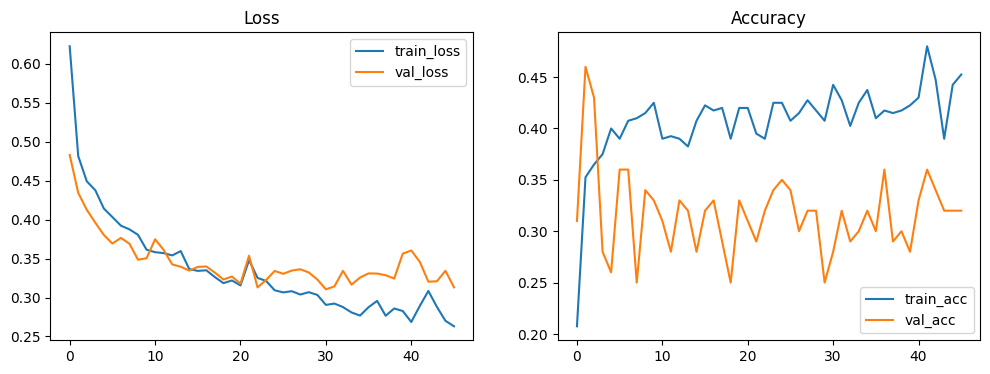

In [22]:
def plot_history(hist):
    plt.figure(figsize=(12, 4))
    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['loss'], label='train_loss')
    plt.plot(hist.history['val_loss'], label='val_loss')
    plt.legend()
    plt.title('Loss')
    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['accuracy'], label='train_acc')
    plt.plot(hist.history['val_accuracy'], label='val_acc')
    plt.legend()
    plt.title('Accuracy')
    plt.show()

plot_history(history)



In [23]:
y_pred_prob = model.predict(X_val_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int)

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("---- Classification Report (por etiqueta) ----")
print(classification_report(y_val, y_pred, target_names=all_cols))

print("---- Métricas detalladas por etiqueta ----")
print("Precision:", precision_score(y_val, y_pred, average=None))
print("Recall:   ", recall_score(y_val, y_pred, average=None))
print("F1-score: ", f1_score(y_val, y_pred, average=None))

4/4 [==============================] - 3s 44ms/step
---- Classification Report (por etiqueta) ----
                         precision    recall  f1-score   support

        giro_incompleto       0.86      0.61      0.71        41
pierna_patea_flexionada       0.00      0.00      0.00         5
 pierna_base_flexionada       0.50      0.12      0.20         8
  pie_sin_borde_externo       0.97      0.87      0.92        38
 preparacion_incompleta       0.89      0.55      0.68        31
    recojida_incompleta       0.71      0.63      0.67        35
                   lado       1.00      0.98      0.99        57

              micro avg       0.90      0.72      0.80       215
              macro avg       0.71      0.54      0.60       215
           weighted avg       0.86      0.72      0.78       215
            samples avg       0.69      0.59      0.61       215

---- Métricas detalladas por etiqueta ----
Precision: [0.86206897 0.         0.5        0.97058824 0.89473684 0.709677

c:\Users\user\anaconda3\envs\tesis2\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\user\anaconda3\envs\tesis2\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\user\anaconda3\envs\tesis2\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\user\anaconda3\envs\t

c:\Users\user\anaconda3\envs\tesis2\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


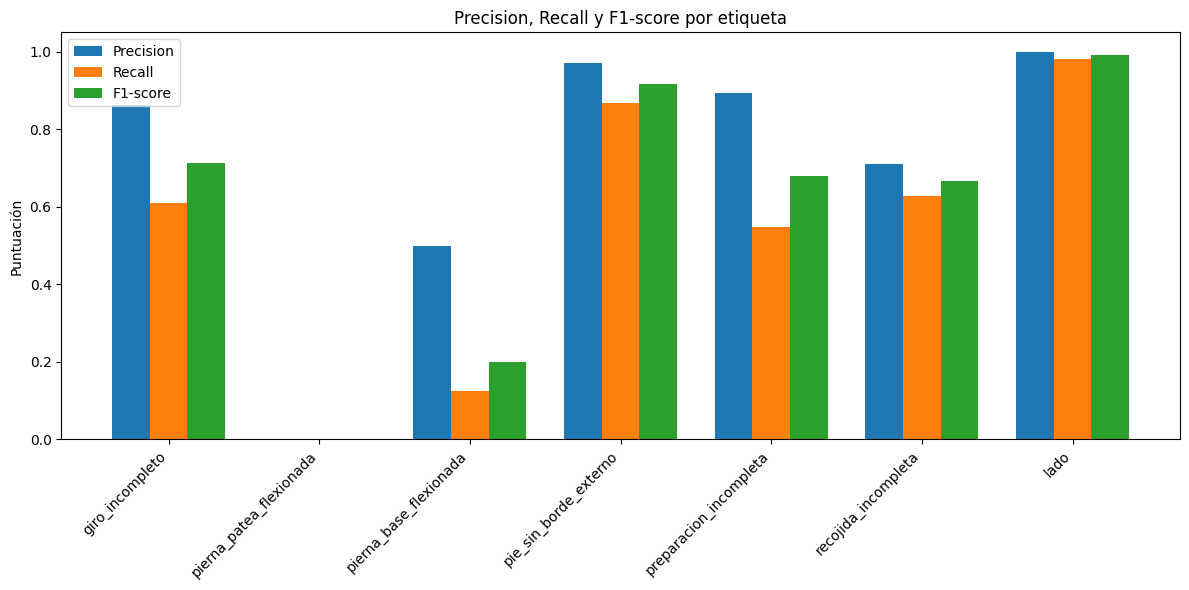

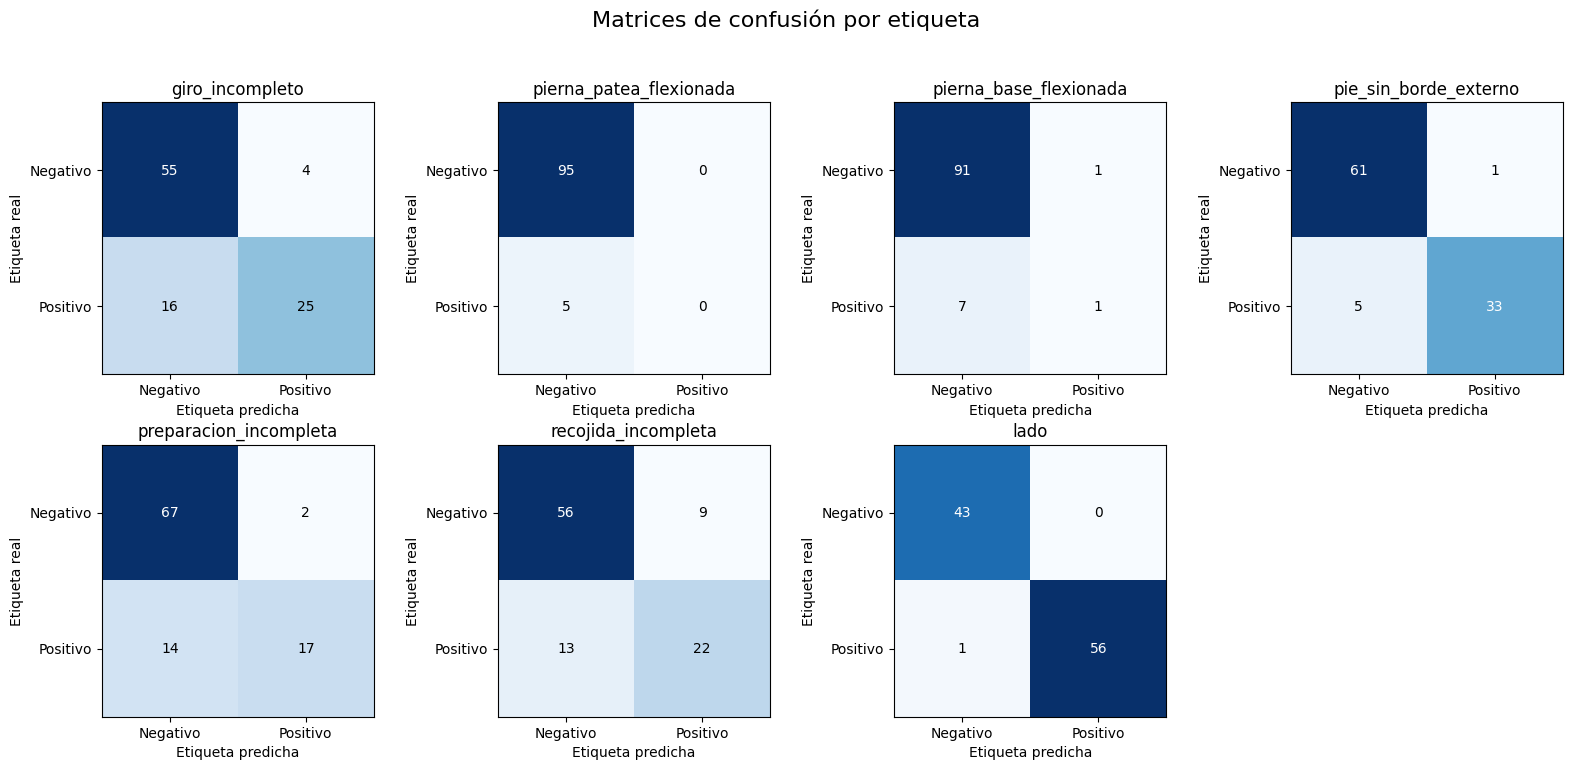

In [24]:
# 1) Cálculo de métricas por etiqueta
precisions = precision_score(y_val, y_pred, average=None)
recalls = recall_score(y_val, y_pred, average=None)
f1s = f1_score(y_val, y_pred, average=None)

# 2) Gráfico de barras: precision, recall y f1-score por etiqueta
x = np.arange(len(all_cols))  # posiciones en el eje x para cada etiqueta
width = 0.25  # ancho de cada barra

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, precisions, width, label='Precision')
ax.bar(x, recalls, width, label='Recall')
ax.bar(x + width, f1s, width, label='F1-score')

ax.set_xticks(x)
ax.set_xticklabels(all_cols, rotation=45, ha='right')
ax.set_ylabel('Puntuación')
ax.set_title('Precision, Recall y F1-score por etiqueta')
ax.legend()
plt.tight_layout()
plt.show()

# 3) Matrices de confusión para cada etiqueta
num_labels = len(all_cols)
rows = 2
cols = 4  # acomodamos 7 etiquetas en 2 filas x 4 columnas, dejando una celda vacía

fig, axes = plt.subplots(rows, cols, figsize=(16, 8))
fig.suptitle('Matrices de confusión por etiqueta', fontsize=16)

for idx, label in enumerate(all_cols):
    row = idx // cols
    col = idx % cols
    cm = confusion_matrix(y_val[:, idx], y_pred[:, idx])
    
    ax = axes[row, col]
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(label)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Negativo', 'Positivo'])
    ax.set_yticklabels(['Negativo', 'Positivo'])
    ax.set_ylabel('Etiqueta real')
    ax.set_xlabel('Etiqueta predicha')
    
    # Anotar valores en cada celda
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

# Ocultar la última celda si no se usa (7 etiquetas → 8 celdas)
if num_labels < rows * cols:
    last_row = (num_labels // cols)
    last_col = num_labels % cols
    axes[last_row, last_col].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()